# Project 11 — Multimodal Fake News Detection
## Notebook 2: Image Download & Preparation from URLs

**Goal:** Extract and download images from article URLs for train/val/test splits.  
**Strategy:** Web scraping using BeautifulSoup + image validation/resizing.  
**Output:** Organized image folders + image manifest CSVs with metadata.

### Notebook Structure
1. Setup & imports
2. Load train/val/test splits
3. Image extraction from article URLs
4. Image validation & filtering
5. Organize & save images by split
6. Create image manifests
7. Statistics & quality report
8. Create unified multimodal dataset (text + image paths)
9. Summary & readiness check

---
## Section 1 — Setup & Imports

In [24]:
# ── Install required packages (run once) ──────────────────────────────────────
import subprocess, sys
pkgs = ['requests', 'beautifulsoup4', 'Pillow', 'lxml', 'tqdm']
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', p], check=False)
print('All packages ready.')

All packages ready.


In [3]:
import os
import re
import json
import warnings
import hashlib
from pathlib import Path
from urllib.parse import urljoin, urlparse
from collections import defaultdict, Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import requests
from PIL import Image
from io import BytesIO
from bs4 import BeautifulSoup
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style='whitegrid', palette='muted')

print('All imports successful.')

All imports successful.


c:\Users\DPQUAI250128\AppData\Local\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ── Configuration ─────────────────────────────────────────────────────────────
SEED = 42
SPLITS = ['train', 'val', 'test']
IMAGE_DIR = Path('images')
MANIFEST_DIR = Path('image_manifests')

# Image download parameters
MAX_IMAGES_PER_ARTICLE = 3  # Only download top 3 images per article
MIN_IMAGE_SIZE = (100, 100)  # Minimum width x height
MAX_IMAGE_SIZE = (2000, 2000)  # Maximum width x height
TIMEOUT = 10  # seconds per URL request
ALLOWED_FORMATS = {'JPEG', 'PNG', 'GIF', 'WEBP', 'BMP'}

# Create directories
for split in SPLITS:
    (IMAGE_DIR / split).mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

print(f'Image directory: {IMAGE_DIR}')
print(f'Manifest directory: {MANIFEST_DIR}')
print(f'Configuration: max_images_per_article={MAX_IMAGES_PER_ARTICLE}, '
      f'min_size={MIN_IMAGE_SIZE}, timeout={TIMEOUT}s')

Image directory: images
Manifest directory: image_manifests
Configuration: max_images_per_article=3, min_size=(100, 100), timeout=10s


---
## Section 2 — Load Train/Val/Test Splits

In [5]:
# Load the three splits
train_df = pd.read_csv('data_splits/train.csv')
val_df   = pd.read_csv('data_splits/val.csv')
test_df  = pd.read_csv('data_splits/test.csv')

print(f'Train: {len(train_df):,} rows')
print(f'Val:   {len(val_df):,} rows')
print(f'Test:  {len(test_df):,} rows')
print(f'Total: {len(train_df) + len(val_df) + len(test_df):,} rows')

# Create a mapping: split_name -> dataframe
splits_data = {
    'train': train_df,
    'val': val_df,
    'test': test_df
}

# Check URLs
for split_name, df in splits_data.items():
    missing = df['news_url'].isnull().sum()
    print(f'{split_name}: {missing} missing URLs')

Train: 320 rows
Val:   40 rows
Test:  40 rows
Total: 400 rows
train: 14 missing URLs
val: 2 missing URLs
test: 5 missing URLs


---
## Section 3 — Image Extraction Functions

In [28]:
def extract_images_from_url(url: str, max_images: int = 3, timeout: int = 10) -> list:
    """
    Extract image URLs from a web page.
    Returns list of tuples: (image_url, source_type)
    """
    if not isinstance(url, str) or len(url.strip()) == 0:
        return []
    
    images = []
    try:
        # Add scheme if missing
        if not url.startswith(('http://', 'https://')):
            url = 'https://' + url
        
        # Fetch page
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        response = requests.get(url, timeout=timeout, headers=headers)
        response.raise_for_status()
        
        # Parse HTML
        soup = BeautifulSoup(response.content, 'html.parser')
        
        # 1. Look for og:image (most reliable)
        og_image = soup.find('meta', property='og:image')
        if og_image and og_image.get('content'):
            img_url = urljoin(url, og_image['content'])
            images.append((img_url, 'og:image'))
        
        # 2. Look for <img> tags with high priority (class contains 'featured', 'hero', 'main')
        for img_tag in soup.find_all('img'):
            if len(images) >= max_images:
                break
            img_url = img_tag.get('src') or img_tag.get('data-src')
            if img_url:
                img_url = urljoin(url, img_url)
                # Prefer images from main content (heuristic)
                if any(x in (img_tag.get('class', []) or []) for x in ['featured', 'hero', 'main', 'article']):
                    images.insert(0, (img_url, 'img_featured'))
                else:
                    images.append((img_url, 'img_general'))
        
        # Trim to max_images
        images = images[:max_images]
    
    except Exception as e:
        pass  # Silently fail
    
    return images

print('extract_images_from_url() defined.')

extract_images_from_url() defined.


In [29]:
def download_and_validate_image(img_url: str, timeout: int = 10) -> Image.Image:
    """
    Download an image from URL and validate it.
    Returns PIL Image object or None if validation fails.
    """
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        response = requests.get(img_url, timeout=timeout, headers=headers)
        response.raise_for_status()
        
        # Open image
        img = Image.open(BytesIO(response.content))
        
        # Validate format
        if img.format and img.format.upper() not in ALLOWED_FORMATS:
            return None
        
        # Validate size
        w, h = img.size
        if w < MIN_IMAGE_SIZE[0] or h < MIN_IMAGE_SIZE[1]:
            return None
        if w > MAX_IMAGE_SIZE[0] or h > MAX_IMAGE_SIZE[1]:
            # Resize if too large
            ratio = min(MAX_IMAGE_SIZE[0] / w, MAX_IMAGE_SIZE[1] / h)
            new_w, new_h = int(w * ratio), int(h * ratio)
            img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
        
        # Convert to RGB if needed
        if img.mode in ('RGBA', 'LA', 'P'):
            rgb_img = Image.new('RGB', img.size, (255, 255, 255))
            rgb_img.paste(img, mask=img.split()[-1] if img.mode == 'RGBA' else None)
            img = rgb_img
        elif img.mode != 'RGB':
            img = img.convert('RGB')
        
        return img
    
    except Exception as e:
        return None

print('download_and_validate_image() defined.')

download_and_validate_image() defined.


---
## Section 4 — Download Images for Each Split

In [30]:
# Track statistics
stats = {
    'train': {'total_articles': 0, 'articles_with_images': 0, 'images_saved': 0, 'errors': 0},
    'val': {'total_articles': 0, 'articles_with_images': 0, 'images_saved': 0, 'errors': 0},
    'test': {'total_articles': 0, 'articles_with_images': 0, 'images_saved': 0, 'errors': 0}
}

# Store image metadata: article_id -> list of image paths
image_manifest = {
    'train': [],
    'val': [],
    'test': []
}

print('Starting image download...')
print('='*70)

for split_name, df in splits_data.items():
    print(f'\nProcessing {split_name.upper()} split ({len(df)} articles)...')
    split_dir = IMAGE_DIR / split_name
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=split_name):
        article_id = row['id']
        url = row['news_url']
        label = row['label']
        
        stats[split_name]['total_articles'] += 1
        
        if pd.isnull(url):
            stats[split_name]['errors'] += 1
            continue
        
        # Extract image URLs from page
        extracted_urls = extract_images_from_url(str(url), max_images=MAX_IMAGES_PER_ARTICLE, timeout=TIMEOUT)
        
        if not extracted_urls:
            continue
        
        article_images = []
        
        # Download each image
        for img_idx, (img_url, source_type) in enumerate(extracted_urls):
            img = download_and_validate_image(img_url, timeout=TIMEOUT)
            
            if img is None:
                continue
            
            # Generate filename
            img_hash = hashlib.md5((img_url).encode()).hexdigest()[:8]
            filename = f'{article_id}_{img_idx}_{img_hash}.jpg'
            filepath = split_dir / filename
            
            # Save image
            try:
                img.save(filepath, 'JPEG', quality=90)
                article_images.append({
                    'image_filename': filename,
                    'image_path': str(filepath.relative_to(Path.cwd())),
                    'image_url': img_url,
                    'source_type': source_type,
                    'size': img.size
                })
                stats[split_name]['images_saved'] += 1
            except Exception as e:
                stats[split_name]['errors'] += 1
        
        # Store metadata if images were saved
        if article_images:
            stats[split_name]['articles_with_images'] += 1
            image_manifest[split_name].append({
                'article_id': article_id,
                'label': label,
                'source': row['source'],
                'n_images': len(article_images),
                'images': article_images
            })

print('\n' + '='*70)
print('Image download complete!')

Starting image download...

Processing TRAIN split (320 articles)...


train: 100%|██████████| 320/320 [20:32<00:00,  3.85s/it]



Processing VAL split (40 articles)...


val: 100%|██████████| 40/40 [00:49<00:00,  1.24s/it]



Processing TEST split (40 articles)...


test: 100%|██████████| 40/40 [01:12<00:00,  1.81s/it]


Image download complete!


---
## Section 5 — Statistics & Quality Report

In [8]:
# Compute statistics from image manifests
manifest_stats = {}
for split_name in SPLITS:
    manifest_path = MANIFEST_DIR / f'{split_name}_image_manifest.csv'
    if manifest_path.exists():
        df_manifest = pd.read_csv(manifest_path)
        articles_with_images = df_manifest['article_id'].nunique()
        total_images = len(df_manifest)
        manifest_stats[split_name] = {
            'articles_with_images': articles_with_images,
            'total_images': total_images
        }
    else:
        manifest_stats[split_name] = {'articles_with_images': 0, 'total_images': 0}

print('\n' + '='*70)
print('IMAGE MANIFEST STATISTICS')
print('='*70)

for split_name in SPLITS:
    s = manifest_stats[split_name]
    total_articles = len(splits_data[split_name])
    print(f'\n{split_name.upper()}:')
    print(f'  Total articles: {total_articles}')
    
    if total_articles > 0:
        coverage = 100 * s["articles_with_images"] / total_articles
        print(f'  Articles with images: {s["articles_with_images"]} ({coverage:.1f}%)')
        print(f'  Total images: {s["total_images"]}')
        if s['articles_with_images'] > 0:
            print(f'  Avg images per article: {s["total_images"] / s["articles_with_images"]:.2f}')
    else:
        print('  No data available.')

print('\n' + '='*70)


IMAGE MANIFEST STATISTICS

TRAIN:
  Total articles: 320
  Articles with images: 110 (34.4%)
  Total images: 216
  Avg images per article: 1.96

VAL:
  Total articles: 40
  Articles with images: 9 (22.5%)
  Total images: 22
  Avg images per article: 2.44

TEST:
  Total articles: 40
  Articles with images: 12 (30.0%)
  Total images: 20
  Avg images per article: 1.67



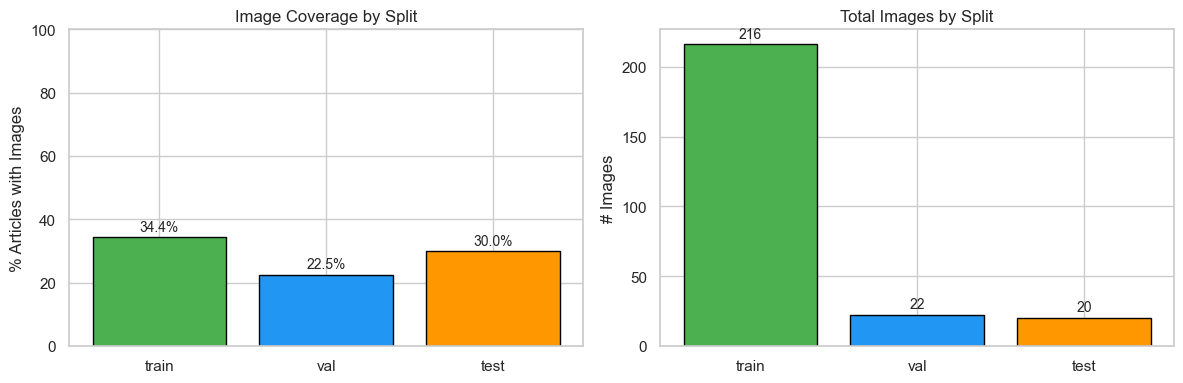

In [ ]:
# Visualize coverage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Coverage per split
splits_list = list(SPLITS)
coverage = [manifest_stats[s]['articles_with_images'] / len(splits_data[s]) * 100 for s in splits_list]
axes[0].bar(splits_list, coverage, color=['#4CAF50', '#2196F3', '#FF9800'], edgecolor='black')
axes[0].set_title('Image Coverage by Split', fontsize=12)
axes[0].set_ylabel('% Articles with Images')
axes[0].set_ylim(0, 100)
for i, v in enumerate(coverage):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=10)

# Total images
image_counts = [manifest_stats[s]['total_images'] for s in splits_list]
axes[1].bar(splits_list, image_counts, color=['#4CAF50', '#2196F3', '#FF9800'], edgecolor='black')
axes[1].set_title('Total Images by Split', fontsize=12)
axes[1].set_ylabel('# Images')
for i, v in enumerate(image_counts):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plot_image_download_stats.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 — Create Image Manifests

In [33]:
# Rebuild image manifests from the actual downloaded image files
split_article_images = {split: {} for split in SPLITS}
split_image_records = {split: [] for split in SPLITS}

for split_name, df in splits_data.items():
    id_map = {row['id']: {'label': row['label'], 'source': row['source']} for _, row in df.iterrows()}
    split_dir = IMAGE_DIR / split_name
    if not split_dir.exists():
        continue

    for image_path in sorted(split_dir.glob('*')):
        if image_path.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.webp', '.gif', '.bmp']:
            continue

        filename = image_path.name
        parts = filename.rsplit('_', 2)
        article_id = parts[0] if len(parts) == 3 else image_path.stem

        if article_id not in split_article_images[split_name]:
            split_article_images[split_name][article_id] = []
        split_article_images[split_name][article_id].append(str(image_path))

        split_image_records[split_name].append({
            'article_id': article_id,
            'label': id_map.get(article_id, {}).get('label', None),
            'source': id_map.get(article_id, {}).get('source', None),
            'image_filename': filename,
            'image_path': str(image_path),
            'image_index': int(parts[1]) if len(parts) == 3 and parts[1].isdigit() else None,
            'image_ext': image_path.suffix.lower()
        })

for split_name in SPLITS:
    manifest_json_path = MANIFEST_DIR / f'{split_name}_image_manifest.json'
    manifest_data = []
    for article_id, image_paths in split_article_images[split_name].items():
        manifest_data.append({
            'article_id': article_id,
            'n_images': len(image_paths),
            'image_paths': image_paths
        })
    with open(manifest_json_path, 'w', encoding='utf-8') as f:
        json.dump(manifest_data, f, indent=2)
    print(f'Saved: {manifest_json_path} ({len(manifest_data)} articles with images)')

    df_manifest = pd.DataFrame(split_image_records[split_name])
    csv_path = MANIFEST_DIR / f'{split_name}_image_manifest.csv'
    df_manifest.to_csv(csv_path, index=False)
    print(f'Saved: {csv_path} ({len(df_manifest)} rows)')

print('\nManifests created successfully.')


Saved: image_manifests\train_image_manifest.json (110 articles with images)
Saved: image_manifests\train_image_manifest.csv (216 rows)
Saved: image_manifests\val_image_manifest.json (9 articles with images)
Saved: image_manifests\val_image_manifest.csv (22 rows)
Saved: image_manifests\test_image_manifest.json (12 articles with images)
Saved: image_manifests\test_image_manifest.csv (20 rows)

Manifests created successfully.


---
## Section 7 — Create Unified Multimodal Dataset

In [34]:
# For each split, merge original data with image paths
for split_name in SPLITS:
    df_original = splits_data[split_name].copy()
    manifest_path = MANIFEST_DIR / f'{split_name}_image_manifest.csv'

    if manifest_path.exists():
        df_manifest = pd.read_csv(manifest_path)
        article_to_images = df_manifest.groupby('article_id')['image_path'].apply(list).to_dict()
    else:
        article_to_images = {}

    df_original['has_image'] = df_original['id'].isin(article_to_images.keys())
    df_original['image_path_primary'] = df_original['id'].map(
        lambda x: article_to_images.get(x, [None])[0]
    )
    df_original['image_paths'] = df_original['id'].map(
        lambda x: ';'.join(article_to_images.get(x, [])) if x in article_to_images else ''
    )
    df_original['n_images_downloaded'] = df_original['id'].map(
        lambda x: len(article_to_images.get(x, []))
    )
    df_original['usable_image'] = df_original['has_image']
    if 'usable_text' in df_original.columns:
        df_original['usable_both'] = df_original['usable_text'] & df_original['usable_image']

    output_path = Path('data_splits') / f'{split_name}_multimodal.csv'
    df_original.to_csv(output_path, index=False)

    n_with_images = df_original['has_image'].sum()
    coverage = 100 * n_with_images / len(df_original)
    print(f'{split_name}: {n_with_images}/{len(df_original)} articles have images ({coverage:.1f}%)')
    print(f'  Saved: {output_path}')

print('\nMultimodal datasets created successfully.')


train: 110/320 articles have images (34.4%)
  Saved: data_splits\train_multimodal.csv
val: 9/40 articles have images (22.5%)
  Saved: data_splits\val_multimodal.csv
test: 12/40 articles have images (30.0%)
  Saved: data_splits\test_multimodal.csv

Multimodal datasets created successfully.


In [35]:
print('\n' + '='*70)
print('MULTIMODAL DATASET READINESS CHECK')
print('='*70)

for split_name in SPLITS:
    # Load multimodal dataset
    df = pd.read_csv(Path('data_splits') / f'{split_name}_multimodal.csv')
    
    print(f'\n{split_name.upper()}:')
    print(f'  Total rows: {len(df)}')
    print(f'  Rows with images: {df["has_image"].sum()}')
    print(f'  Coverage: {100*df["has_image"].mean():.1f}%')
    print(f'  Fake/Real balance: {df[df["has_image"]].groupby("label").size().to_dict()}')
    print(f'  Columns: {df.columns.tolist()}')

print('\n' + '='*70)
print('✓ Image download & preparation complete!')
print('✓ Ready for multimodal model training!')
print('='*70)


MULTIMODAL DATASET READINESS CHECK

TRAIN:
  Total rows: 320
  Rows with images: 110
  Coverage: 34.4%
  Fake/Real balance: {'fake': 62, 'real': 48}
  Columns: ['id', 'news_url', 'title', 'tweet_ids', 'source', 'label', 'title_len_chars', 'title_len_words', 'title_has_null', 'title_is_empty', 'title_is_url', 'title_all_caps', 'title_punct_density', 'title_exclaim_count', 'title_question_count', 'n_tweet_ids', 'url_missing', 'domain', 'url_len', 'usable_text', 'usable_image', 'usable_both', 'has_image', 'image_path_primary', 'image_paths', 'n_images_downloaded']

VAL:
  Total rows: 40
  Rows with images: 9
  Coverage: 22.5%
  Fake/Real balance: {'fake': 3, 'real': 6}
  Columns: ['id', 'news_url', 'title', 'tweet_ids', 'source', 'label', 'title_len_chars', 'title_len_words', 'title_has_null', 'title_is_empty', 'title_is_url', 'title_all_caps', 'title_punct_density', 'title_exclaim_count', 'title_question_count', 'n_tweet_ids', 'url_missing', 'domain', 'url_len', 'usable_text', 'usable_i